<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/Ad_Targeting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
df = pd.read_csv("/content/ad_click_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 9)


,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


In [3]:
display(df.info())
display(df.describe(include="all"))

print("Missing values:")
display(df.isna().sum())

print("Overall Click Through Rate (CTR):", round(df["click"].mean(), 4))

df["click"].value_counts(normalize=True).rename("proportion")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  object 
 2   age               5234 non-null   float64
 3   gender            5307 non-null   object 
 4   device_type       8000 non-null   object 
 5   ad_position       8000 non-null   object 
 6   browsing_history  5218 non-null   object 
 7   time_of_day       8000 non-null   object 
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


None

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
count,10000.000000,10000,5234.000000,5307,8000,8000,5218,8000,10000.000000
unique,NaN,4000,NaN,3,3,3,5,4,NaN
top,NaN,User1171,NaN,Female,Desktop,Bottom,Entertainment,Morning,NaN
freq,NaN,25,NaN,1834,2754,2817,1175,2126,NaN
mean,5060.211400,NaN,40.197363,NaN,NaN,NaN,NaN,NaN,0.650000
std,2861.758265,NaN,13.126420,NaN,NaN,NaN,NaN,NaN,0.476993
min,5.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,2529.000000,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,5218.000000,NaN,39.500000,NaN,NaN,NaN,NaN,NaN,1.000000
75%,7466.000000,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,1.000000


Missing values:


,0
id,0
full_name,0
age,4766
gender,4693
device_type,2000
ad_position,2000
browsing_history,4782
time_of_day,2000
click,0


Overall Click Through Rate (CTR): 0.65


,proportion
click,
1,0.65
0,0.35


In [4]:
identifier_cols = ["id", "full_name"]
target_col = "click"

X_raw = df.drop(columns=identifier_cols + [target_col])
y_click = df[target_col].copy()

X_raw["is_mobile_user"] = (X_raw["device_type"] == "Mobile").astype(int)

numeric_cols = ["age", "is_mobile_user"]
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), categorical_cols)
    ],
    remainder="drop"
)

X = preprocessor.fit_transform(X_raw)


cat_feature_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(cat_feature_names)

X_df = pd.DataFrame(X, columns=feature_names)
print("Processed feature shape:", X_df.shape)
X_df.head()

Processed feature shape: (10000, 20)


,age,is_mobile_user,gender_Female,gender_Male,gender_Non-Binary,device_type_Desktop,device_type_Mobile,device_type_Tablet,ad_position_Bottom,ad_position_Side,ad_position_Top,browsing_history_Education,browsing_history_Entertainment,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,-1.880137,-0.600299,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-0.038413,-0.600299,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.119449,-0.600299,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.617240,-0.600299,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.091034,-0.600299,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [5]:
def evaluate_kmeans(X_matrix, k_range=range(3, 9), model_name="KMeans"):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_matrix)
        rows.append({
            "model": model_name,
            "k": k,
            "inertia": km.inertia_,
            "silhouette_score": silhouette_score(X_matrix, labels),
            "davies_bouldin_index": davies_bouldin_score(X_matrix, labels)
        })
    return pd.DataFrame(rows)

def plot_k_selection(metrics_df, title_prefix):
    plt.figure(figsize=(8, 4))
    plt.plot(metrics_df["k"], metrics_df["inertia"], marker="o")
    plt.title(f"{title_prefix}: Elbow Method")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Inertia / SSE")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(metrics_df["k"], metrics_df["silhouette_score"], marker="o")
    plt.title(f"{title_prefix}: Silhouette Score")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

def cluster_ctr_table(data, label_col):
    out = data.groupby(label_col).agg(
        users=("click", "size"),
        clicks=("click", "sum"),
        ctr=("click", "mean"),
        avg_age=("age", "mean")
    ).reset_index()
    out["ctr"] = out["ctr"].round(4)
    out["avg_age"] = out["avg_age"].round(2)
    return out.sort_values("ctr", ascending=False)

def profile_clusters(original_df, label_col):
    rows = []
    for cluster, part in original_df.groupby(label_col):
        row = {
            "cluster": cluster,
            "users": len(part),
            "ctr": round(part["click"].mean(), 4),
            "avg_age": round(part["age"].mean(), 2),
            "top_gender": part["gender"].mode(dropna=True).iloc[0] if not part["gender"].mode(dropna=True).empty else "Unknown",
            "top_device": part["device_type"].mode(dropna=True).iloc[0] if not part["device_type"].mode(dropna=True).empty else "Unknown",
            "top_ad_position": part["ad_position"].mode(dropna=True).iloc[0] if not part["ad_position"].mode(dropna=True).empty else "Unknown",
            "top_browsing_history": part["browsing_history"].mode(dropna=True).iloc[0] if not part["browsing_history"].mode(dropna=True).empty else "Unknown",
            "top_time_of_day": part["time_of_day"].mode(dropna=True).iloc[0] if not part["time_of_day"].mode(dropna=True).empty else "Unknown",
        }
        rows.append(row)
    return pd.DataFrame(rows).sort_values("ctr", ascending=False)

def business_recommendation(profile_df):
    avg_ctr = df["click"].mean()
    high = profile_df[profile_df["ctr"] >= avg_ctr].copy()
    low = profile_df[profile_df["ctr"] < avg_ctr].copy()

    high_share = min(70, 50 + int((len(high) / len(profile_df)) * 20)) if len(high) else 50
    low_share = 100 - high_share

    print("Overall CTR:", round(avg_ctr, 4))
    print("Recommended budget split:")
    print(f"- Allocate about {high_share}% of budget to above-average CTR clusters.")
    print(f"- Keep about {low_share}% for testing, retargeting, or low-cost inventory in below-average CTR clusters.")
    print("- Prioritize creative variations based on the top device, browsing category, ad position, and time of day of the high-CTR clusters.")

,model,k,inertia,silhouette_score,davies_bouldin_index
0,ML_KMeans,3,33570.855208,0.217885,1.668840
1,ML_KMeans,4,30832.868894,0.190196,1.910538
2,ML_KMeans,5,29335.090063,0.171316,2.012012
3,ML_KMeans,6,27839.591518,0.165745,1.911324
4,ML_KMeans,7,26494.756452,0.153341,1.977484
5,ML_KMeans,8,25547.219013,0.136832,2.108333


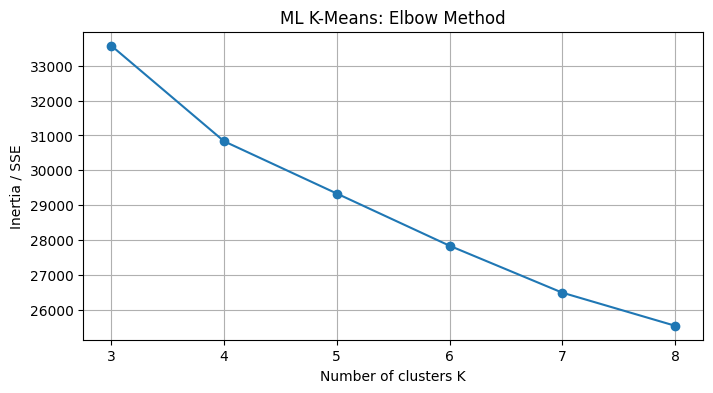

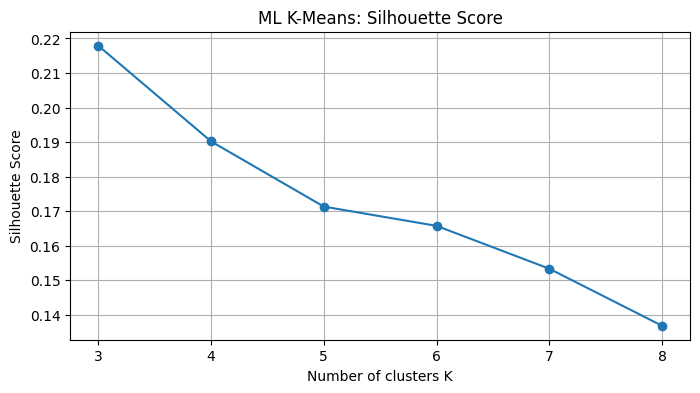

Selected K for ML K-Means: 3


In [6]:
ml_metrics = evaluate_kmeans(X_df, range(3, 9), "ML_KMeans")
display(ml_metrics)
plot_k_selection(ml_metrics, "ML K-Means")

optimal_k_ml = int(ml_metrics.sort_values(["silhouette_score", "davies_bouldin_index"], ascending=[False, True]).iloc[0]["k"])
print("Selected K for ML K-Means:", optimal_k_ml)

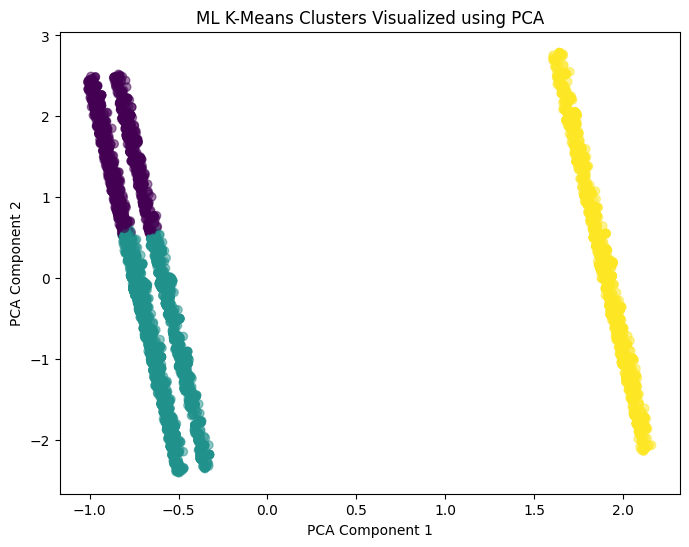

Explained variance by 2 PCA components: 0.4523


In [7]:
km_ml = KMeans(n_clusters=optimal_k_ml, random_state=RANDOM_STATE, n_init=10)
ml_labels = km_ml.fit_predict(X_df)

result_df = df.copy()
result_df["ml_cluster"] = ml_labels

pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2.fit_transform(X_df)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ml_labels, alpha=0.5)
plt.title("ML K-Means Clusters Visualized using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

print("Explained variance by 2 PCA components:", pca_2.explained_variance_ratio_.sum().round(4))

ML Cluster CTR Table


,ml_cluster,users,clicks,ctr,avg_age
1,1,5958,3990,0.6697,32.01
2,2,2649,1678,0.6334,39.28
0,0,1393,832,0.5973,55.26


ML Cluster Profiles


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
1,1,5958,0.6697,32.01,Male,Desktop,Bottom,Entertainment,Morning
2,2,2649,0.6334,39.28,Female,Mobile,Bottom,Social Media,Morning
0,0,1393,0.5973,55.26,Female,Tablet,Side,Social Media,Afternoon


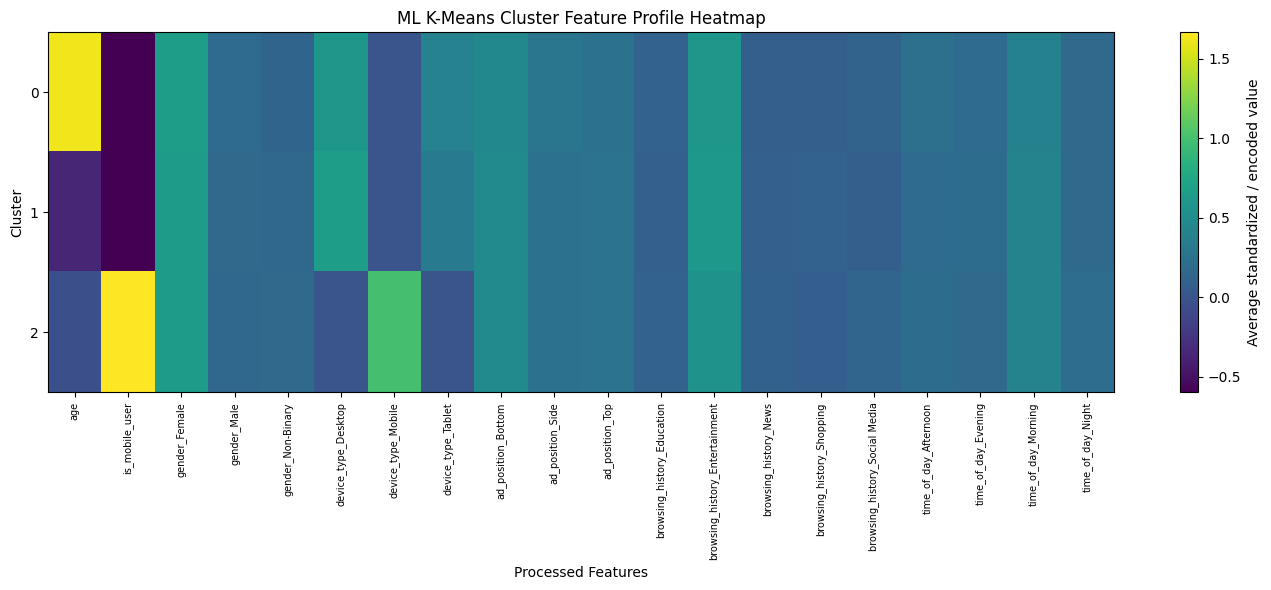

In [9]:
ml_profiles = profile_clusters(result_df, "ml_cluster")
ml_ctr = cluster_ctr_table(result_df, "ml_cluster")

print("ML Cluster CTR Table")
display(ml_ctr)

print("ML Cluster Profiles")
display(ml_profiles)

cluster_feature_means = X_df.copy()
cluster_feature_means["cluster"] = ml_labels
cluster_feature_means = cluster_feature_means.groupby("cluster").mean()

plt.figure(figsize=(14, 6))
plt.imshow(cluster_feature_means, aspect="auto")
plt.title("ML K-Means Cluster Feature Profile Heatmap")
plt.xlabel("Processed Features")
plt.ylabel("Cluster")
plt.colorbar(label="Average standardized / encoded value")
plt.xticks(range(len(cluster_feature_means.columns)), cluster_feature_means.columns, rotation=90, fontsize=7)
plt.yticks(range(len(cluster_feature_means.index)), cluster_feature_means.index)
plt.tight_layout()
plt.show()

In [10]:
input_dim = X_df.shape[1]
latent_dim = 8

input_layer = keras.Input(shape=(input_dim,), name="input")
x = layers.Dense(32, activation="relu")(input_layer)
x = layers.Dense(16, activation="relu")(x)
latent_layer = layers.Dense(latent_dim, activation="relu", name="latent_features")(x)
x = layers.Dense(16, activation="relu")(latent_layer)
x = layers.Dense(32, activation="relu")(x)
output_layer = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(input_layer, output_layer, name="autoencoder")
encoder = keras.Model(input_layer, latent_layer, name="encoder")

autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,684 (10.48 KB)

 Trainable params: 2,684 (10.48 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.3071 - val_loss: 0.2486
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2207 - val_loss: 0.1817
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1652 - val_loss: 0.1472
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1375 - val_loss: 0.1210
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1140 - val_loss: 0.1028
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0987 - val_loss: 0.0906
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0881 - val_loss: 0.0823
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0800 - val_loss: 0.0756
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0744 - val_loss: 0.0714
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0707 - val_loss: 0.0681
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0678 - val_loss: 0.0655
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0

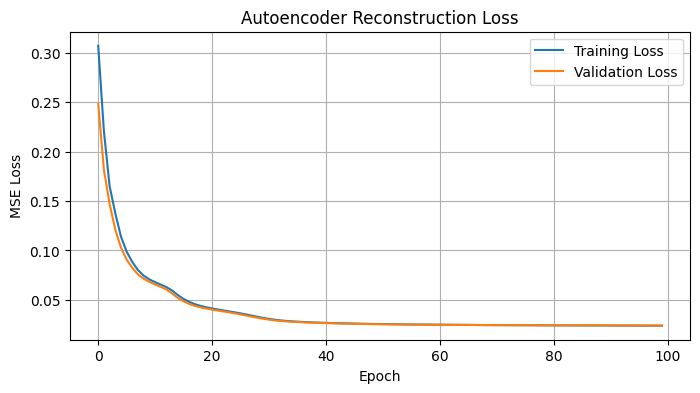

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_df, X_df,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


,model,k,inertia,silhouette_score,davies_bouldin_index
0,DL_Autoencoder_KMeans,3,33198.050781,0.513482,0.785202
1,DL_Autoencoder_KMeans,4,28721.529297,0.434308,0.923676
2,DL_Autoencoder_KMeans,5,25868.128906,0.394391,1.063340
3,DL_Autoencoder_KMeans,6,23085.898438,0.362078,1.144642
4,DL_Autoencoder_KMeans,7,20438.125000,0.298541,1.311196
5,DL_Autoencoder_KMeans,8,18707.500000,0.310303,1.248274


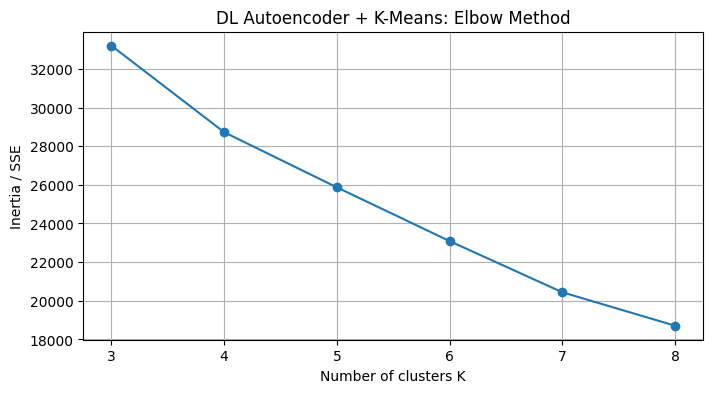

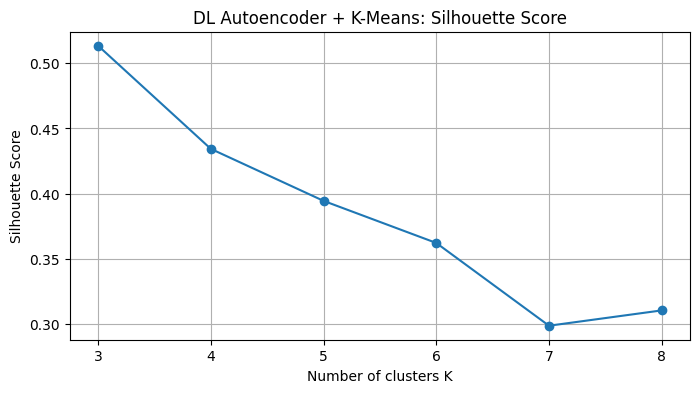

Selected K for DL Autoencoder + K-Means: 3


In [12]:
latent_features = encoder.predict(X_df)
latent_df = pd.DataFrame(latent_features, columns=[f"latent_{i+1}" for i in range(latent_dim)])

dl_metrics = evaluate_kmeans(latent_df, range(3, 9), "DL_Autoencoder_KMeans")
display(dl_metrics)
plot_k_selection(dl_metrics, "DL Autoencoder + K-Means")

optimal_k_dl = int(dl_metrics.sort_values(["silhouette_score", "davies_bouldin_index"], ascending=[False, True]).iloc[0]["k"])
print("Selected K for DL Autoencoder + K-Means:", optimal_k_dl)

km_dl = KMeans(n_clusters=optimal_k_dl, random_state=RANDOM_STATE, n_init=10)
dl_labels = km_dl.fit_predict(latent_df)
result_df["dl_cluster"] = dl_labels

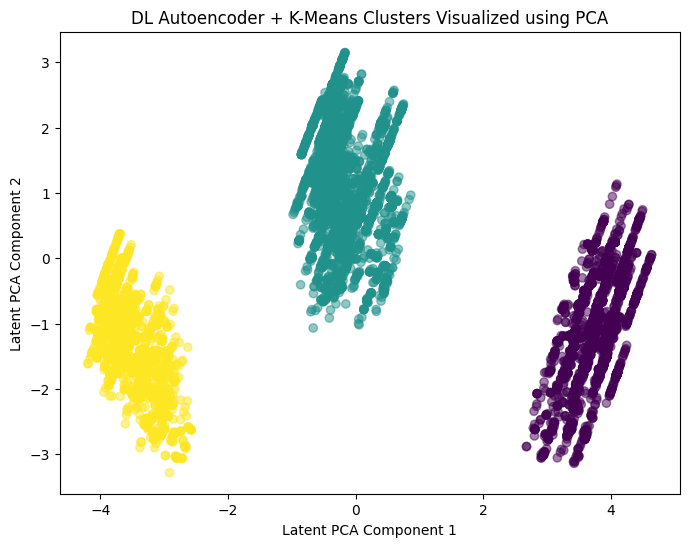

Explained variance by 2 latent PCA components: 0.7773


In [13]:
pca_latent = PCA(n_components=2, random_state=RANDOM_STATE)
latent_pca = pca_latent.fit_transform(latent_df)

plt.figure(figsize=(8, 6))
plt.scatter(latent_pca[:, 0], latent_pca[:, 1], c=dl_labels, alpha=0.5)
plt.title("DL Autoencoder + K-Means Clusters Visualized using PCA")
plt.xlabel("Latent PCA Component 1")
plt.ylabel("Latent PCA Component 2")
plt.show()

print("Explained variance by 2 latent PCA components:", pca_latent.explained_variance_ratio_.sum().round(4))

In [14]:
ml_final = ml_metrics[ml_metrics["k"] == optimal_k_ml].copy()
dl_final = dl_metrics[dl_metrics["k"] == optimal_k_dl].copy()

ml_profiles = profile_clusters(result_df, "ml_cluster")
dl_profiles = profile_clusters(result_df, "dl_cluster")

comparison = pd.DataFrame({
    "Metric": [
        "Selected K",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Max CTR",
        "Min CTR",
        "CTR Spread"
    ],
    "ML K-Means": [
        optimal_k_ml,
        round(float(ml_final["silhouette_score"].iloc[0]), 4),
        round(float(ml_final["davies_bouldin_index"].iloc[0]), 4),
        round(float(ml_profiles["ctr"].max()), 4),
        round(float(ml_profiles["ctr"].min()), 4),
        round(float(ml_profiles["ctr"].max() - ml_profiles["ctr"].min()), 4)
    ],
    "DL Autoencoder + KMeans": [
        optimal_k_dl,
        round(float(dl_final["silhouette_score"].iloc[0]), 4),
        round(float(dl_final["davies_bouldin_index"].iloc[0]), 4),
        round(float(dl_profiles["ctr"].max()), 4),
        round(float(dl_profiles["ctr"].min()), 4),
        round(float(dl_profiles["ctr"].max() - dl_profiles["ctr"].min()), 4)
    ]
})

display(comparison)

print("ML Profiles")
display(ml_profiles)

print("DL Profiles")
display(dl_profiles)

,Metric,ML K-Means,DL Autoencoder + KMeans
0,Selected K,3.0000,3.0000
1,Silhouette Score,0.2179,0.5135
2,Davies-Bouldin Index,1.6688,0.7852
3,Max CTR,0.6697,0.6603
4,Min CTR,0.5973,0.6334
5,CTR Spread,0.0724,0.0269


ML Profiles


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
1,1,5958,0.6697,32.01,Male,Desktop,Bottom,Entertainment,Morning
2,2,2649,0.6334,39.28,Female,Mobile,Bottom,Social Media,Morning
0,0,1393,0.5973,55.26,Female,Tablet,Side,Social Media,Afternoon


DL Profiles


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
1,1,4754,0.6603,39.98,Male,Desktop,Bottom,Entertainment,Morning
2,2,2597,0.6481,41.56,Male,Tablet,Bottom,Education,Evening
0,0,2649,0.6334,39.28,Female,Mobile,Bottom,Social Media,Morning


In [15]:
ml_ctr_spread = ml_profiles["ctr"].max() - ml_profiles["ctr"].min()
dl_ctr_spread = dl_profiles["ctr"].max() - dl_profiles["ctr"].min()

if dl_ctr_spread > ml_ctr_spread:
    winning_model = "DL Autoencoder + K-Means"
    winning_cluster_col = "dl_cluster"
    winning_profiles = dl_profiles
else:
    winning_model = "ML K-Means"
    winning_cluster_col = "ml_cluster"
    winning_profiles = ml_profiles

print("Winning model:", winning_model)
print("Reason: selected using the largest CTR spread, with internal metrics used as supporting evidence.")
display(winning_profiles)

Winning model: ML K-Means
Reason: selected using the largest CTR spread, with internal metrics used as supporting evidence.


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
1,1,5958,0.6697,32.01,Male,Desktop,Bottom,Entertainment,Morning
2,2,2649,0.6334,39.28,Female,Mobile,Bottom,Social Media,Morning
0,0,1393,0.5973,55.26,Female,Tablet,Side,Social Media,Afternoon


In [16]:
business_recommendation(winning_profiles)

high_ctr_clusters = winning_profiles[winning_profiles["ctr"] >= df["click"].mean()]
low_ctr_clusters = winning_profiles[winning_profiles["ctr"] < df["click"].mean()]

print("High CTR clusters:")
display(high_ctr_clusters)

print("Low CTR clusters:")
display(low_ctr_clusters)

Overall CTR: 0.65
Recommended budget split:
- Allocate about 56% of budget to above-average CTR clusters.
- Keep about 44% for testing, retargeting, or low-cost inventory in below-average CTR clusters.
- Prioritize creative variations based on the top device, browsing category, ad position, and time of day of the high-CTR clusters.
High CTR clusters:


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
1,1,5958,0.6697,32.01,Male,Desktop,Bottom,Entertainment,Morning


Low CTR clusters:


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
2,2,2649,0.6334,39.28,Female,Mobile,Bottom,Social Media,Morning
0,0,1393,0.5973,55.26,Female,Tablet,Side,Social Media,Afternoon


In [18]:
def make_final_answers():
    overall_ctr = df["click"].mean()
    win = winning_profiles.sort_values("ctr", ascending=False).reset_index(drop=True)
    best = win.iloc[0]
    worst = win.iloc[-1]

    print("1. Optimal K Selection")
    print(f"For the initial ML K-Means model, the selected K is {optimal_k_ml}. For the Autoencoder + K-Means model, the selected K is {optimal_k_dl}. These values balance statistical separation with practical campaign execution. Too few clusters hide useful differences, while too many clusters make targeting difficult to manage.")

    print("\n2. Initial K-Means Segment Characteristics")
    print("The ML K-Means profiles show the baseline differences in age, device type, browsing context, ad position, and time of day. These clusters provide a first-level understanding of user groups and help identify broad patterns in ad engagement.")
    display(ml_profiles)

    print("\n3. Autoencoder Latent Feature Impact")
    print("The Autoencoder compresses the original processed features into latent features that capture non-linear similarities among users. This can reveal relationships that ordinary K-Means on raw encoded features may miss, especially when categorical behavior patterns interact with age and device usage.")

    print("\n4. Compactness and Separation")
    print("The preferred technical model is identified by comparing Silhouette Score and Davies-Bouldin Index. A higher Silhouette Score and lower DB Index indicate better-separated and more compact clusters, which reduces wasteful ad spend by making each segment more internally consistent.")
    display(comparison)

    print("\n5. CTR Disparity")
    print(f"The winning model is {winning_model}. It creates the strongest separation between the highest CTR cluster ({best['ctr']}) and lowest CTR cluster ({worst['ctr']}). This difference is the main evidence that the segmentation can separate high-value from low-value users.")

    print("\n6. Highest CTR Cluster Strategy")
    print(f"The highest CTR cluster is Cluster {best['cluster']} with CTR {best['ctr']}. Its dominant traits are: device = {best['top_device']}, browsing = {best['top_browsing_history']}, ad position = {best['top_ad_position']}, time = {best['top_time_of_day']}, average age = {best['avg_age']}. The company should increase budget for this segment and design creatives aligned with this context.")

    print("\n7. Lowest CTR Cluster Strategy")
    print(f"The lowest CTR cluster is Cluster {worst['cluster']} with CTR {worst['ctr']}. Its dominant traits are: device = {worst['top_device']}, browsing = {worst['top_browsing_history']}, ad position = {worst['top_ad_position']}, time = {worst['top_time_of_day']}, average age = {worst['avg_age']}. The company should reduce spend here or move this group to cheaper awareness campaigns.")

    print("\n8. Quantitative Budget Recommendation")
    high_clusters = win[win["ctr"] >= overall_ctr]
    low_clusters = win[win["ctr"] < overall_ctr]
    print(f"Overall CTR is {overall_ctr:.4f}. Reallocate approximately 20% to 30% of budget away from below-average CTR clusters and into the top-performing clusters. Keep a small test budget for low-CTR clusters to monitor changes, but prioritize the highest CTR segments for performance campaigns.")

    print("\n9. Deployment Recommendation")
    print(f"Deploy {winning_model} because it provides the strongest business separation in CTR while also being supported by internal cluster quality metrics. Better mathematical separation means users inside each segment are more similar, so campaign messages and bidding strategies can be more focused.")

make_final_answers()

1. Optimal K Selection
For the initial ML K-Means model, the selected K is 3. For the Autoencoder + K-Means model, the selected K is 3. These values balance statistical separation with practical campaign execution. Too few clusters hide useful differences, while too many clusters make targeting difficult to manage.

2. Initial K-Means Segment Characteristics
The ML K-Means profiles show the baseline differences in age, device type, browsing context, ad position, and time of day. These clusters provide a first-level understanding of user groups and help identify broad patterns in ad engagement.


,cluster,users,ctr,avg_age,top_gender,top_device,top_ad_position,top_browsing_history,top_time_of_day
1,1,5958,0.6697,32.01,Male,Desktop,Bottom,Entertainment,Morning
2,2,2649,0.6334,39.28,Female,Mobile,Bottom,Social Media,Morning
0,0,1393,0.5973,55.26,Female,Tablet,Side,Social Media,Afternoon



3. Autoencoder Latent Feature Impact
The Autoencoder compresses the original processed features into latent features that capture non-linear similarities among users. This can reveal relationships that ordinary K-Means on raw encoded features may miss, especially when categorical behavior patterns interact with age and device usage.

4. Compactness and Separation
The preferred technical model is identified by comparing Silhouette Score and Davies-Bouldin Index. A higher Silhouette Score and lower DB Index indicate better-separated and more compact clusters, which reduces wasteful ad spend by making each segment more internally consistent.


,Metric,ML K-Means,DL Autoencoder + KMeans
0,Selected K,3.0000,3.0000
1,Silhouette Score,0.2179,0.5135
2,Davies-Bouldin Index,1.6688,0.7852
3,Max CTR,0.6697,0.6603
4,Min CTR,0.5973,0.6334
5,CTR Spread,0.0724,0.0269



5. CTR Disparity
The winning model is ML K-Means. It creates the strongest separation between the highest CTR cluster (0.6697) and lowest CTR cluster (0.5973). This difference is the main evidence that the segmentation can separate high-value from low-value users.

6. Highest CTR Cluster Strategy
The highest CTR cluster is Cluster 1 with CTR 0.6697. Its dominant traits are: device = Desktop, browsing = Entertainment, ad position = Bottom, time = Morning, average age = 32.01. The company should increase budget for this segment and design creatives aligned with this context.

7. Lowest CTR Cluster Strategy
The lowest CTR cluster is Cluster 0 with CTR 0.5973. Its dominant traits are: device = Tablet, browsing = Social Media, ad position = Side, time = Afternoon, average age = 55.26. The company should reduce spend here or move this group to cheaper awareness campaigns.

8. Quantitative Budget Recommendation
Overall CTR is 0.6500. Reallocate approximately 20% to 30% of budget away from be